### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

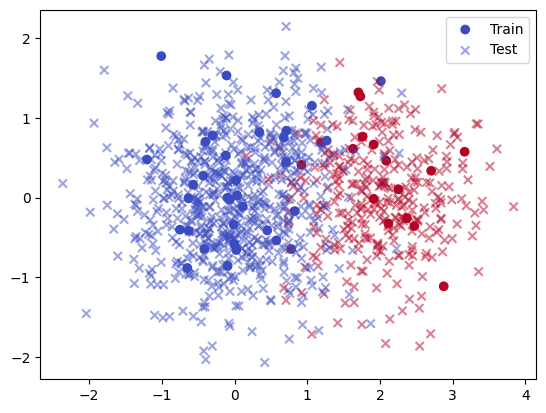

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def create_n_points(n, epsilon, p):
    x_list = []
    y_list = []
    mu0 = np.array([0,0])
    mu1 = np.array([epsilon, 0])
    sig0 = np.array([[0.5, 0],[0, 0.5]])
    sig1 = np.array([[0.4, 0],[0, 0.4]])
    for i in range(n):
        if np.random.rand() < p:
            y = 1
        else:
            y = 0
        if y == 0:
            x = np.random.multivariate_normal(mu0, sig0)
        else:
            x = np.random.multivariate_normal(mu1, sig1)
        x_list.append(x)
        y_list.append(y)
    return (x_list, y_list)

# Convert to numpy arrays for easier slicing

D_train = create_n_points(50, 2, 0.3)
D_test = create_n_points(1000, 2, 0.3)

X_train = np.array(D_train[0])
y_train = np.array(D_train[1])

X_test = np.array(D_test[0])
y_test = np.array(D_test[1])

# Plot train data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', marker='o', label='Train')

# Plot test data
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='x', alpha=0.5, label='Test')

plt.legend()
plt.show()

            

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

The optimal Bayes classifier is:

$$
f^*(x) =
\begin{cases}
1 & \text{if } \dfrac{P(Y=1 \mid x)}{P(Y=0 \mid x)} > 1 \\
0 & \text{otherwise}
\end{cases}
$$

Using Bayes' rule:

$$
\frac{P(Y=1 \mid x)}{P(Y=0 \mid x)}
=
\frac{p \, P(x \mid Y=1)}{(1-p)\, P(x \mid Y=0)}
$$

Thus, the decision boundary is defined by:

$$
\frac{p \, P(x \mid Y=1)}{(1-p)\, P(x \mid Y=0)} = 1
$$

Since $P(x \mid Y=i) \sim \mathcal{N}(\mu_i, \Sigma_i)$, we have:

$$
1 =
\frac{p}{1-p}
\cdot
\frac{|\Sigma_0|^{1/2}}{|\Sigma_1|^{1/2}}
\cdot
\exp\left(
+\frac{1}{2}(x-\mu_0)^T \Sigma_0^{-1}(x-\mu_0)
-\frac{1}{2}(x-\mu_1)^T \Sigma_1^{-1}(x-\mu_1)
\right)
$$

With

$$
\mu_0 = (0,0)^T, \quad
\mu_1 = (\epsilon,0)^T, \quad
\Sigma_0 = 0.5\, I, \quad
\Sigma_1 = 0.4\, I,
$$

$$
|\Sigma_0| = 0.25, \quad
|\Sigma_1| = 0.16, \quad
\Sigma_0^{-1} = 2I, \quad
\Sigma_1^{-1} = 2.5I,
$$

the boundary becomes:

$$
1 =
\frac{p}{1-p}
\cdot
\frac{0.5}{0.4}
\cdot
\exp\left(
+(x_1^2 + x_2^2)
-\frac{2.5}{2} \left((x_1 - \epsilon)^2 + x_2^2 \right)
\right)
$$

where $x = (x_1, x_2)^T$.
which is the same as
$$
ln(\frac{1-p}{1.25p}) =
+ (x_1^2 + x_2^2)
-\frac{2.5}{2} \left((x_1 - \epsilon)^2 + x_2^2 \right)
$$

So, by denoting $h(x) = + (x_1^2 + x_2^2) - \frac{2.5}{2} \left((x_1 - \epsilon)^2 + x_2^2 \right)$

We get :

$$
f^*(x) =
\begin{cases}
1 & \text{if } h(x) >  ln(\frac{1-p}{1.25p}) \\
0 & \text{otherwise}
\end{cases}
$$

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

For epsilon = 2, p = 0.3:
Accuracy = 0.9421
Precision = 0.9003412969283277
Error Rate = 0.05789999999999995


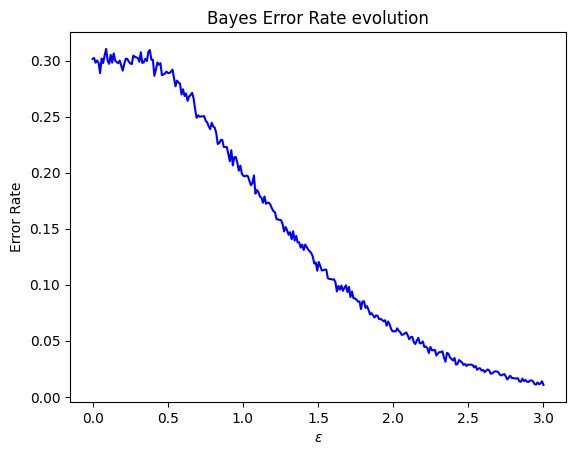

In [2]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

class BayesClassifier:
    def __init__(self, epsilon, p):
        self.epsilon = epsilon
        self.p = p
        
    def fit(self, X=None, y=None) :
        self.X_ = X
        self.y_ = y
        return self

    def predict(self, X):
        decision_boundary = np.log((1 - self.p) / (1.25 * self.p))
        h_x = + (X[:, 0]**2 + X[:, 1]**2) - (2.5 / 2) * ((X[:, 0] - self.epsilon)**2 + X[:, 1]**2)
        return (h_x > decision_boundary).astype(int)

epsilon = 2
p = 0.3

D_test2 = create_n_points(10000, epsilon, 0.3)
X_test2 = np.array(D_test2[0])
y_test2 = np.array(D_test2[1])
bc = BayesClassifier(epsilon, p)
y_pred = bc.predict(X_test2)

accuracy = accuracy_score(y_test2, y_pred)
precision = precision_score(y_test2, y_pred)
print(f"For epsilon = {epsilon}, p = {p}:")
print(f"Accuracy = {accuracy}") # proportion correct
print(f"Precision = {precision}") # tp / (tp + fp)
print(f"Error Rate = {1 - accuracy}")
bayesErrorRate = 1 - accuracy

epsilonArray = np.linspace(0, 3, 300)
errorRateArray = []
for epsilon in epsilonArray:
    bc = BayesClassifier(epsilon, p)
    D_new = create_n_points(10000, epsilon, 0.3)

    X_testNew = np.array(D_new[0])
    y_testNew = np.array(D_new[1])
    y_predNew = bc.predict(X_testNew)

    errorRate = 1 - accuracy_score(y_testNew , y_predNew)
    errorRateArray.append(errorRate)

plt.plot(epsilonArray, errorRateArray, "b-")
plt.xlabel(fr"$\varepsilon$")
plt.ylabel("Error Rate")
plt.title("Bayes Error Rate evolution")
plt.show()


When the value of $\varepsilon$ increases, the classes become more separated, since they are centered at different coordinates. In consequence, it is easier for the Bayes classifier to separate both classes, causing the error rate to decrease.

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

Both classes are generated with a normal distribution, so a Gaussian Discriminant Analysis methods seem pertinent, and the covariance matrix is different for both of them (So no LDA). The assumptions needed for the best performance QDA are verified, so it seems to be the most adequate in this case.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


D_test = create_n_points(1000, 2, 0.3)
X_test = np.array(D_test[0])
y_test = np.array(D_test[1])

LDA = LinearDiscriminantAnalysis()
QDA = QuadraticDiscriminantAnalysis()
lr = LogisticRegression()

LDA.fit(X_train, y_train)
QDA.fit(X_train, y_train)
lr.fit(X_train, y_train)

y_predLDA = LDA.predict(X_test)
y_predQDA = QDA.predict(X_test)
y_predLR = lr.predict(X_test)

errorRateLDA = 1 - accuracy_score(y_test, y_predLDA)
errorRateQDA = 1 - accuracy_score(y_test, y_predQDA)
errorRateLR = 1 - accuracy_score(y_test, y_predLR)
print(f"Error Rate for LDA = {errorRateLDA}")
print(f"Error Rate for QDA = {errorRateQDA}")
print(f"Error Rate for Logistic Regression = {errorRateLR}")
print(f"Error Rate for Bayes Classifier = {1 - accuracy}")


Error Rate for LDA = 0.05900000000000005
Error Rate for QDA = 0.07199999999999995
Error Rate for Logistic Regression = 0.06299999999999994
Error Rate for Bayes Classifier = 0.05789999999999995


All the three error rates are approximately equal, however most of the times QDA gives the lowest error, which is expected because its assumptions match the true model.
Theoritically, we can say that the bayes classifier achieves the irreducible error
LDA assumes equal covariance matrices, which is not true here. Logistic regression assumes a linear boundary, while the true Bayes Boundary is non linear.
Therefore their errors are slightly larger.
As the training sample size increases, parameter estimates become more accurate (Strong law of large numbers), so the test errors should decrease and approach the Bayes error rate. 

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [4]:
D_test = create_n_points(1000, 0.5, 0.7)
X_test = np.array(D_test[0])
y_test = np.array(D_test[1])

y_predLDA = LDA.predict(X_test)
y_predQDA = QDA.predict(X_test)
y_predLR = lr.predict(X_test)
y_predBC = bc.predict(X_test)

errorRateLDA = 1 - accuracy_score(y_test, y_predLDA)
errorRateQDA = 1 - accuracy_score(y_test, y_predQDA)
errorRateLR = 1 - accuracy_score(y_test, y_predLR)
errorRateBC = 1 - accuracy_score(y_test, y_predBC)
print(f"Error Rate for LDA = {errorRateLDA}")
print(f"Error Rate for QDA = {errorRateQDA}")
print(f"Error Rate for Logistic Regression = {errorRateLR}")
print(f"Error Rate for BC = {errorRateBC}")

Error Rate for LDA = 0.607
Error Rate for QDA = 0.622
Error Rate for Logistic Regression = 0.627
Error Rate for BC = 0.661


The errors become much larger because the classifiers were trained on a different data distribution.
During training, the prior probability was p=0.3, while in the new test set it becomes p=0.7 Also, the class means are much closer (ϵ=0.5 instead of 2), which increases overlap.
Therefore, the models learned decision boundaries adapted to the old distribution and generalize poorly to the new one.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

In [5]:
from skrub import tabular_pipeline
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd
df_test = pd.read_csv("test.csv")
df_train = pd.read_csv("train.csv")


X_train = df_train.drop(columns=["Survived"])
Y_train = df_train["Survived"]

X_test = df_test


clf = tabular_pipeline("classifier")
clf.fit(X_train, Y_train)
# Print categorical features
print(clf.steps)
preprocessor = clf.named_steps["tablevectorizer"]
# feature_names = preprocessor.get_feature_names_out()
# print(feature_names)
print(preprocessor.transformers_)

#kfold to test accuracy

kf = KFold(n_splits=5, shuffle=True, random_state=0)

scores = cross_val_score(clf, X_train, Y_train, cv=kf, scoring="accuracy")

print(f"Accuracy = {scores.mean()}")








[('tablevectorizer', TableVectorizer(low_cardinality=ToCategorical())), ('histgradientboostingclassifier', HistGradientBoostingClassifier())]
{'PassengerId': PassThrough(), 'Pclass': PassThrough(), 'Age': PassThrough(), 'SibSp': PassThrough(), 'Parch': PassThrough(), 'Fare': PassThrough(), 'Sex': ToCategorical(), 'Embarked': ToCategorical(), 'Name': StringEncoder(), 'Ticket': StringEncoder(), 'Cabin': StringEncoder()}
Accuracy = 0.8338899001945892


Numerical features are used as they are (PassangerId, Pclass, Age, SibsSp, Parch, Fare).
For categorical features, ToCategorical() is used (one-hot encoding)
For text features, StringEncoder(), which converts string to a numeric vector : Similar strings are associated to similar numeric vectors.


**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

We would like to use a method based from trees or forest, since they can handle missing values and mainting accuracy, and also maintain accuracy in high dimension . Boosting approaches are known for reducing variance and bias, so we decided to use a boosting approach. 

In the complementary course, we saw that XGBoost is a strong method (the one that gave better results for classification problems), and is used for general tabular data, and also it manages missing values automatically, which is useful for our case.

Our score in the public leaderbord in Kaggle is 0.80622



In [6]:
# Using xgboost, presented in the complementary courses
from sklearn.ensemble import GradientBoostingClassifier
from skrub import TableVectorizer
from xgboost import XGBClassifier

gb = GradientBoostingClassifier()
xgb = XGBClassifier()

pp = TableVectorizer()
X_train_proc = pp.fit_transform(X_train)

xgb.fit(X_train_proc,Y_train)
y_pred = xgb.predict(X_train_proc)

kf = KFold(n_splits=5, shuffle=True, random_state=0)

X_test_proc = pp.transform(X_test)

scores2 = cross_val_score(xgb, X_train_proc, Y_train, cv=kf, scoring="accuracy")

print(f"Accuracy = {scores2.mean()}")


preds =  xgb.predict(X_test_proc)
submission = pd.DataFrame({"PassengerId":df_test["PassengerId"],"Survived":preds})

submission.to_csv("submission.csv",index=False)
print("Submission file created")

Accuracy = 0.8372418555018516
Submission file created
